<a href="https://colab.research.google.com/github/abbosaliboev/Computer_Vision/blob/main/2_week.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [42]:
import cv2
import numpy as np
import matplotlib.pyplot as plt
import requests

# Funcotion for download pictures
def download_image(url, filename):
    r = requests.get(url)
    with open(filename, 'wb') as f:
        f.write(r.content)

# List of pictures
urls = {
    "aerial": "https://raw.githubusercontent.com/kjcheoi-class/CV/main/Fig0309(a)(washed_out_aerial_image).tif",
    "pollen": "https://raw.githubusercontent.com/kjcheoi-class/CV/main/Fig0310(b)(washed_out_pollen_image).tif",
    "school": "https://raw.githubusercontent.com/kjcheoi-class/CV/main/school.jpg",
    "finger": "https://raw.githubusercontent.com/kjcheoi-class/CV/main/finger.jpg",
    "wirebond": "https://raw.githubusercontent.com/kjcheoi-class/CV/main/Fig0905(a)(wirebond-mask).tif",
    "headCT": "https://raw.githubusercontent.com/kjcheoi-class/CV/main/Fig0939(a)(headCT-Vandy).tif",
    "cygnus": "https://raw.githubusercontent.com/kjcheoi-class/CV/main/Fig0938(a)(cygnusloop_Xray_original).tif",
    "rice": "https://raw.githubusercontent.com/kjcheoi-class/CV/main/Fig0940(a)(rice_image_with_intensity_gradient).tif",
    "blobs": "https://raw.githubusercontent.com/kjcheoi-class/CV/main/Fig0943(a)(dark_blobs_on_light_background).tif"
}

for name, url in urls.items():
    download_image(url, f"{name}.tif")

# HW#2-1: Gamma Correction

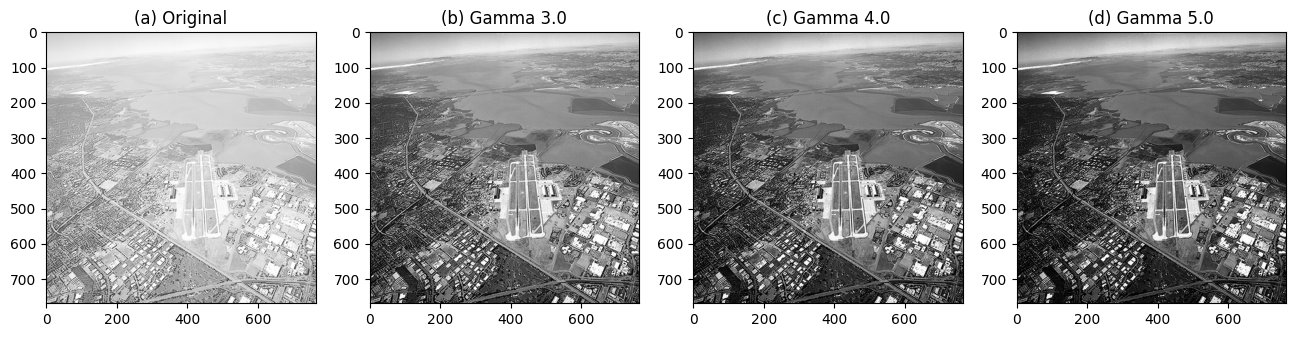

In [4]:
def hw2_1():
    # Read the original image
    img = cv2.imread('aerial.tif', 0)

    # We use 1.0/255.0 to keep values between 0 and 1
    img_norm = img.astype(float) / 255.0

    gammas = [3.0, 4.0, 5.0]
    titles = ['(a) Original', '(b) Gamma 3.0', '(c) Gamma 4.0', '(d) Gamma 5.0']

    plt.figure(figsize=(16, 4))

    # 1. Show Original
    plt.subplot(1, 4, 1)
    plt.imshow(img, cmap='gray')
    plt.title(titles[0])

    # 2. Show Gamma results
    for i, g in enumerate(gammas):
        # Result = (L-1) * (r)^gamma
        res = np.power(img_norm, g)
        res = np.uint8(res * 255) # Change back to 0-255 scale

        plt.subplot(1, 4, i+2)
        plt.imshow(res, cmap='gray')
        plt.title(titles[i+1])

    plt.show()

hw2_1()


Analysis: The original image is too bright (washed out).

Applying gamma > 1 makes the image darker and improves the contrast of the ground.

# HW#2-2: Contrast Stretching

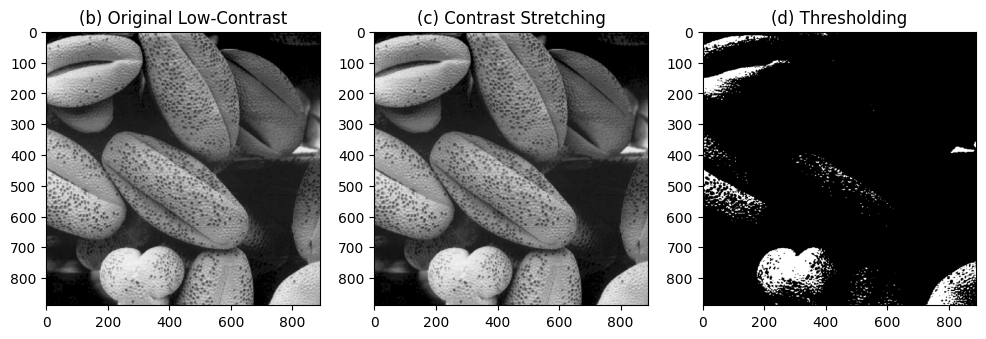

In [5]:
def hw2_2():
    img = cv2.imread('pollen.tif', 0)

    # Method 1: Contrast Stretching
    # This formula stretches the pixel values to 0-255 range
    xp = [img.min(), img.max()]
    fp = [0, 255]
    x = np.arange(256)
    table = np.interp(x, xp, fp).astype('uint8')
    stretched = cv2.LUT(img, table)

    # Method 2: Thresholding
    # Pixels > 127 become 255 (white), others become 0 (black)
    _, thresh = cv2.threshold(img, 127, 255, cv2.THRESH_BINARY)

    plt.figure(figsize=(12, 4))

    plt.subplot(1, 3, 1)
    plt.imshow(img, cmap='gray')
    plt.title('(b) Original Low-Contrast')

    plt.subplot(1, 3, 2)
    plt.imshow(stretched, cmap='gray')
    plt.title('(c) Contrast Stretching')

    plt.subplot(1, 3, 3)
    plt.imshow(thresh, cmap='gray')
    plt.title('(d) Thresholding')

    plt.show()

hw2_2()

Analysis: The original image is hard to see because the colors are very similar.

Stretching makes the image look natural. Thresholding turns it into a clear black and white map.

# HW#2-3: Convolution with Masks




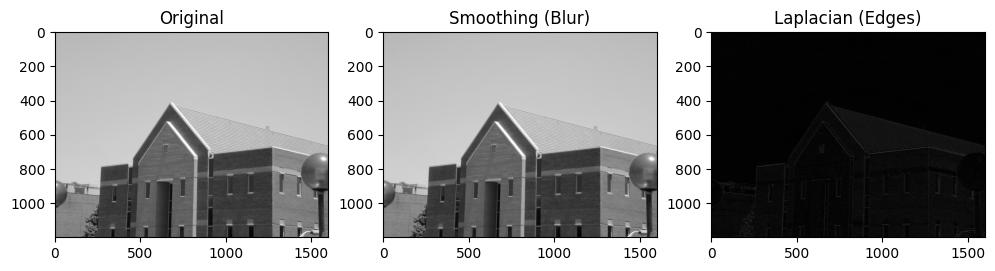

In [8]:
def hw2_3():
    img = cv2.imread('school.tif', 0)

    # 1. Smoothing Mask (1/9)
    blur_kernel = np.ones((3,3), np.float32) / 9
    smooth_img = cv2.filter2D(img, -1, blur_kernel)

    # 2. Laplacian Mask (Sharpening)
    laplace_kernel = np.array([[ 0, -1,  0],
                               [-1,  4, -1],
                               [ 0, -1,  0]])
    laplace_img = cv2.filter2D(img, -1, laplace_kernel)

    plt.figure(figsize=(12, 4))
    plt.subplot(1, 3, 1); plt.imshow(img, cmap='gray'); plt.title('Original')
    plt.subplot(1, 3, 2); plt.imshow(smooth_img, cmap='gray'); plt.title('Smoothing (Blur)')
    plt.subplot(1, 3, 3); plt.imshow(laplace_img, cmap='gray'); plt.title('Laplacian (Edges)')
    plt.show()

hw2_3()

Analysis: Smoothing mask makes the image blurry by averaging pixel values.

Laplacian mask finds the areas of rapid intensity change (edges).

# HW#2-4: Diagonal Edge Detection (Sobel)

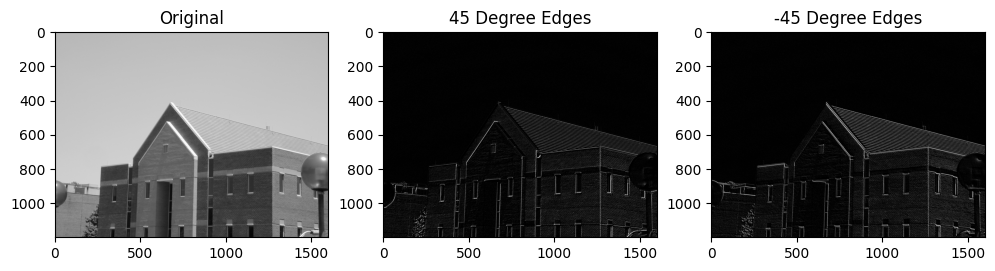

In [7]:
def hw2_4():
    # Used the specific school image for this task
    img = cv2.imread('school.tif', 0)

    # Custom Sobel-style masks for diagonal detection
    # 45 degree mask
    mask_45 = np.array([[-2, -1,  0],
                        [-1,  0,  1],
                        [ 0,  1,  2]])

    # -45 degree mask
    mask_neg45 = np.array([[ 0,  1,  2],
                           [-1,  0,  1],
                           [-2, -1,  0]])

    # Apply filters
    edge_45 = cv2.filter2D(img, -1, mask_45)
    edge_neg45 = cv2.filter2D(img, -1, mask_neg45)

    plt.figure(figsize=(12, 4))
    plt.subplot(1, 3, 1); plt.imshow(img, cmap='gray'); plt.title('Original')
    plt.subplot(1, 3, 2); plt.imshow(edge_45, cmap='gray'); plt.title('45 Degree Edges')
    plt.subplot(1, 3, 3); plt.imshow(edge_neg45, cmap='gray'); plt.title('-45 Degree Edges')
    plt.show()

hw2_4()

Analysis: The 45-degree mask detects lines tilting to the right (like the roof's right side).

The -45-degree mask detects lines tilting to the left (like the roof's left side).

# HW#2-5: Fingerprint Enhancement

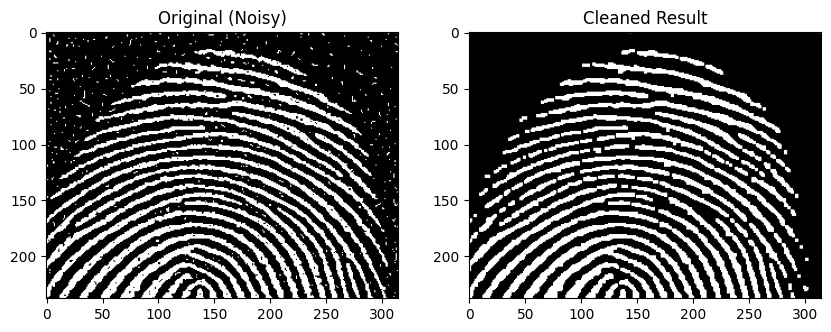

In [11]:
def hw2_5():
    # Read image
    img = cv2.imread('finger.tif', 0)

    if img is None:
        print("Error: Could not find finger.tif. Please check the file name.")
        return

    # 3x3 kernel
    kernel = np.ones((3,3), np.uint8)

    # Closing to fill small dark holes
    closed = cv2.morphologyEx(img, cv2.MORPH_CLOSE, kernel)
    # Opening to remove small white dots
    cleaned = cv2.morphologyEx(closed, cv2.MORPH_OPEN, kernel)

    plt.figure(figsize=(10, 5))
    plt.subplot(1, 2, 1)
    plt.imshow(img, cmap='gray')
    plt.title('Original (Noisy)')

    plt.subplot(1, 2, 2)
    plt.imshow(cleaned, cmap='gray')
    plt.title('Cleaned Result')
    plt.show()

hw2_5()

Analysis: The original image has many white spots and noise.

Using Closing then Opening helps to clear the image and make the lines smooth.

# HW#2-6: Wirebond (Removing Lines)

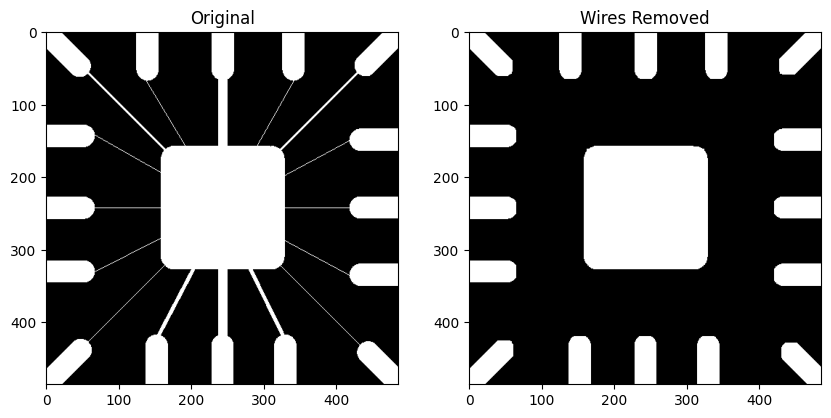

In [12]:
def hw2_6():
    img = cv2.imread('wirebond.tif', 0)

    if img is None:
        print("Error: Could not find wirebond.tif")
        return

    # We use a large 15x15 kernel to remove thin lines
    kernel = np.ones((15,15), np.uint8)
    res = cv2.morphologyEx(img, cv2.MORPH_OPEN, kernel)

    plt.figure(figsize=(10, 5))
    plt.subplot(1, 2, 1); plt.imshow(img, cmap='gray'); plt.title('Original')
    plt.subplot(1, 2, 2); plt.imshow(res, cmap='gray'); plt.title('Wires Removed')
    plt.show()

hw2_6()

Analysis: Opening operation with a large kernel "erases" anything thinner than the kernel.

So the wires disappear and only the big chip centers stay.

# HW#2-7: Edge Detection Comparison

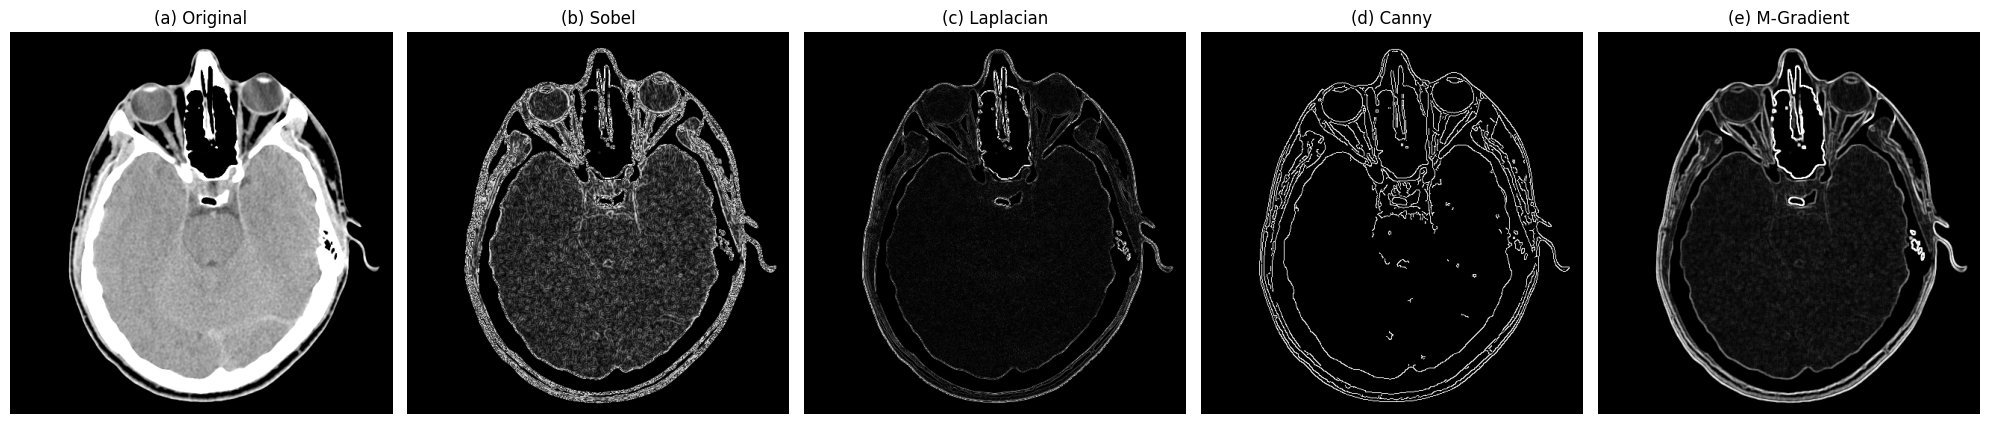

In [38]:
def hw2_7():
    img = cv2.imread('headCT.tif', 0)


    # 1. Sobel Edge Detection
    sobel_x = cv2.Sobel(img, cv2.CV_64F, 1, 0, ksize=3)
    sobel_y = cv2.Sobel(img, cv2.CV_64F, 0, 1, ksize=3)
    sobel = np.sqrt(sobel_x**2 + sobel_y**2)
    sobel = np.uint8(np.absolute(sobel)) # Convert back to 8-bit image

    # 2. Laplacian Edge Detection
    laplace = cv2.Laplacian(img, cv2.CV_64F)

    laplace = np.uint8(np.absolute(laplace))

    # 3. Canny Edge Detection
    canny = cv2.Canny(img, 100, 200)

    # 4. Morphological Gradient
    kernel = np.ones((3,3), np.uint8)
    m_grad = cv2.morphologyEx(img, cv2.MORPH_GRADIENT, kernel)

    # Show all results together to compare
    plt.figure(figsize=(20, 5))

    # List of images and titles for a clean loop
    images = [img, sobel, laplace, canny, m_grad]
    titles = ['(a) Original', '(b) Sobel',
              '(c) Laplacian', '(d) Canny',
              '(e) M-Gradient']

    for i in range(5):
        plt.subplot(1, 5, i+1)
        plt.imshow(images[i], cmap='gray')
        plt.title(titles[i])
        plt.axis('off') # Hide axis numbers

    plt.tight_layout()
    plt.show()

hw2_7()


### Analysis
1. Sobel and Laplacian show many edges but they have some noise.
2. Canny is the best for this CT scan because it shows very clean lines.
3. Morphological Gradient makes the edges look much thicker than others.

# HW#2-8: Morphological Smoothing

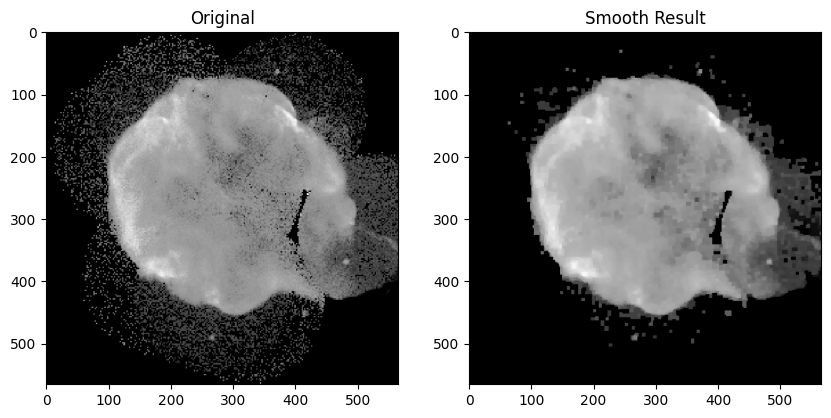

In [50]:
def hw2_8():
    img = cv2.imread('cygnus.tif', 0)
    if img is None: return

    # 5x5 kernel for smoothing
    kernel = np.ones((5,5), np.uint8)

    # Step 1: Opening (removes small bright spots)
    opening = cv2.morphologyEx(img, cv2.MORPH_OPEN, kernel)
    # Step 2: Closing (fills small dark holes)
    smooth = cv2.morphologyEx(opening, cv2.MORPH_CLOSE, kernel)

    plt.figure(figsize=(10, 5))
    plt.subplot(1, 2, 1); plt.imshow(img, cmap='gray'); plt.title('Original')
    plt.subplot(1, 2, 2); plt.imshow(smooth, cmap='gray'); plt.title('Smooth Result')
    plt.show()

hw2_8()

Analysis: Morphological smoothing removes small noise but keeps large objects.

# HW#2-9: Rice Binarization

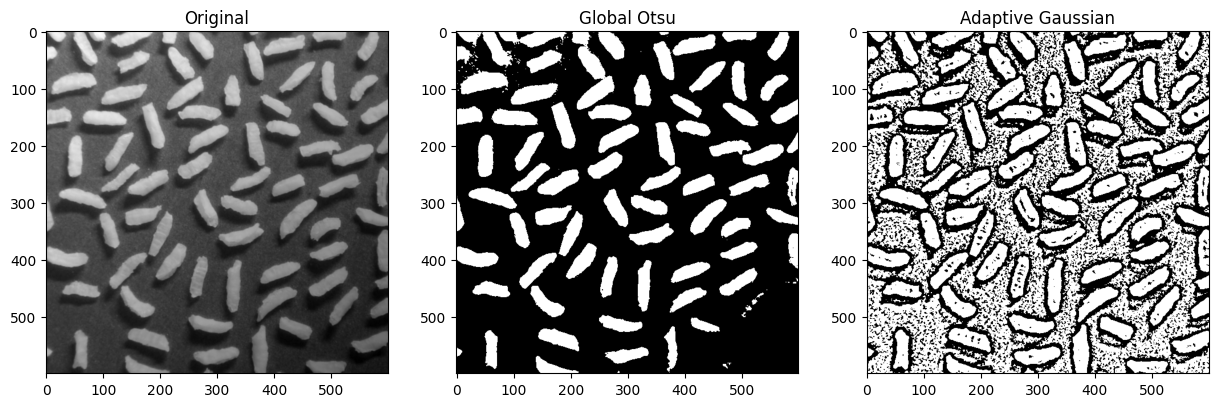

In [51]:
def hw2_9():
    img = cv2.imread('rice.tif', 0)
    if img is None: return

    # Global Otsu thresholding
    _, th1 = cv2.threshold(img, 0, 255, cv2.THRESH_BINARY + cv2.THRESH_OTSU)

    # Adaptive thresholding (better for uneven lighting)
    th2 = cv2.adaptiveThreshold(img, 255, cv2.ADAPTIVE_THRESH_GAUSSIAN_C,
                                cv2.THRESH_BINARY, 21, 2)

    plt.figure(figsize=(15, 5))
    plt.subplot(1, 3, 1); plt.imshow(img, cmap='gray'); plt.title('Original')
    plt.subplot(1, 3, 2); plt.imshow(th1, cmap='gray'); plt.title('Global Otsu')
    plt.subplot(1, 3, 3); plt.imshow(th2, cmap='gray'); plt.title('Adaptive Gaussian')
    plt.show()

hw2_9()

Analysis: Global threshold fails due to uneven light. Adaptive threshold finds all rice grains.

# HW#2-10: Textural Segmentation

Success: Image loaded! Shape: (600, 600, 3)


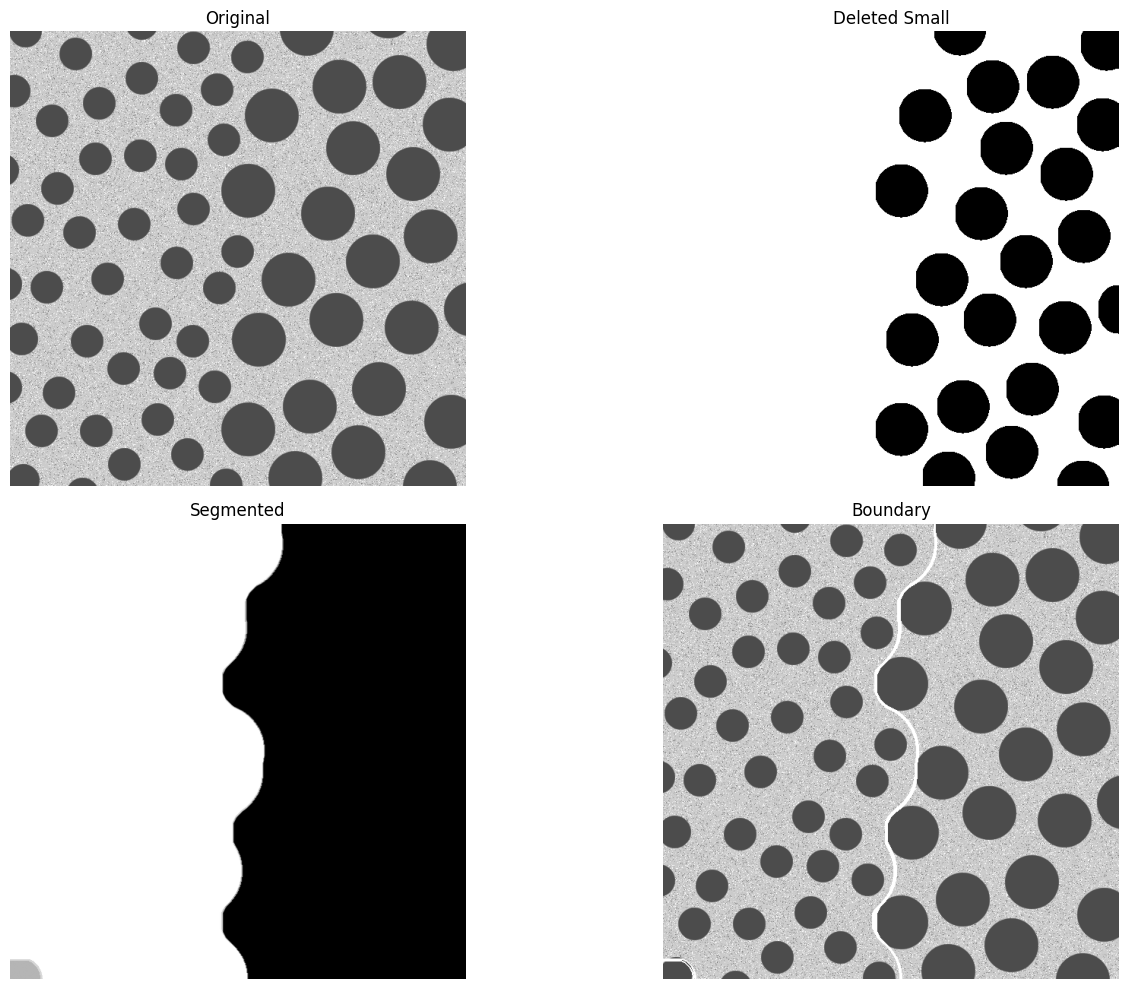

In [69]:
def hw2_10():
    # 1. Read the image
    img = cv2.imread('blobs.tif')

    gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)

    # 2. Step (b): Closing with 50x50 kernel
    k50 = cv2.getStructuringElement(cv2.MORPH_ELLIPSE, (50, 50))
    deletesmall = cv2.morphologyEx(gray, cv2.MORPH_CLOSE, k50)
    _, step_b = cv2.threshold(deletesmall, 100, 255, cv2.THRESH_BINARY)

    # 3. Step (c) : Opening with 120x120 kernel
    k120 = cv2.getStructuringElement(cv2.MORPH_ELLIPSE, (120, 120))
    segment = cv2.morphologyEx(deletesmall, cv2.MORPH_OPEN, k120)

    # 4. Step (d): Boundary
    k3 = cv2.getStructuringElement(cv2.MORPH_ELLIPSE, (3, 3))
    line = cv2.morphologyEx(segment, cv2.MORPH_GRADIENT, k3)
    _, mask = cv2.threshold(line, 0, 255, cv2.THRESH_BINARY)

    # Draw result
    res = img.copy()
    res[mask == 255] = [255, 255, 255]

    # Visualization
    plt.figure(figsize=(15, 10))

    titles = ['Original', 'Deleted Small', 'Segmented', 'Boundary']
    images = [img, step_b, segment, res]

    for i in range(4):
        plt.subplot(2, 2, i+1)
        if i == 0 or i == 3:
            plt.imshow(cv2.cvtColor(images[i], cv2.COLOR_BGR2RGB))
        else:
            plt.imshow(images[i], cmap='gray')
        plt.title(titles[i])
        plt.axis('off')

    plt.tight_layout()
    plt.show() # Forces the display

hw2_10()

Analysis:

Big kernels (50 and 120) help to group the blobs together.

Closing removes small dots, and Opening creates a clean mask for the two regions.